# IND320 Project Work

 - **Github Link :** https://github.com/Mobashra/M-Abeer-Project
 - **Streamlit Link :** https://m-abeer-project.streamlit.app/

### Project Log

This part of the project was to explore weather and electricity production data in Norway using open data sources and data analysis techniques. Here, I utilized the `Open-Meteo ERA5` reanalysis API to collect historical hourly weather data for five cities representing Norway’s electricity price areas: *Oslo, Kristiansand, Trondheim, Tromsø, and Bergen*. The selected variables were **temperature_2m (°C),precipitation (mm),wind_speed_10m (m/s),wind_gusts_10m (m/s),wind_direction_10m (°)**.

A Python function was developed to automatically fetch weather data for any given `latitude`, `longitude`, and `year`. The dataset for Bergen in 2019 was used for detailed analysis. 

To detect temperature anomalies in `Open Meteo Dataset`, the **Discrete Cosine Transform (DCT)** was applied for high-pass filtering, producing seasonally adjusted temperature variations. Outliers were then identified using **Statistical Process Control (SPC)** limits based on robust statistics, with results visualized in a time-series plot. For precipitation, anomalies were detected using the **Local Outlier Factor (LOF)** method, with an adjustable contamination rate *(default 1%)*. This approach effectively highlighted unusual precipitation events throughout the year.

In the second part, **Seasonal-Trend decomposition using LOESS (STL)** was performed on `Elhub Electricity Production Data`. The decomposition separated the production time series into trend, seasonal, and residual components, revealing clear periodic behaviors.
Finally, a spectrogram analysis was implemented to visualize the frequency content of energy production data, demonstrating recurring weekly and seasonal patterns.


The Streamlit app was updated to enhance usability and integrate live API data. The page order was reorganized to 1, 4, new A, 2, 3, new B, 5. The previous CSV import of meteorological data was replaced with the **Open-Meteo API**, using the year `2021` and dynamically linked to the *price area selector* on page 2. 
Two new pages were added with interactive tabs: 
- **new A**: contains STL decomposition in the first tab and spectrogram analysis in the second [Elhub Production Data]
- **new B**: contains temperature outlier/SPC analysis and precipitation anomaly/LOF analysis. [Open Meteo Data]

Both pages display plots, statistics, and adjustable parameters for dynamic exploration.



### AI Usage

In this part of the project, I used ChatGPT primarily to guide me on best practices for coding, *error handling*, and structuring reusable functions. It helped me implement advanced analysis techniques, including seasonally adjusted temperature variations (SATV) using Direct Cosine Transform, Statistical Process Control (SPC) boundaries, and Local Outlier Factor (LOF) analysis for detecting anomalies in temperature and precipitation data. For time series processing, ChatGPT assisted with handling timestamps, interpolating missing values, and creating regular hourly series for both weather and Elhub production datasets. In the STL decomposition and spectrogram analyses, it guided me in setting sensible parameters for period, seasonal, trend, and robust fitting, as well as window length, overlap, and scaling, while also helping to clean up plot labels and formatting.

During the Streamlit development, it suggested reorganizing pages, adding interactive tabs with `st.tabs()` and more styling techniques, and ensuring that plots and statistics updated correctly based on user input. Additionally, it provided guidance on error handling, input validation, and writing reusable, well-commented functions. Furthermore, GPT helped me to add clean UI elements and provided me an idea of what can be included in the statistics. Overall, AI support improved development efficiency, enhanced code quality, and increased the clarity and professionalism of visualizations, while I maintained full understanding and control over all processing steps.


### Importing all necessary libraries

In [1]:
# Basic imports for the notebook
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.tsa.seasonal import STL
from scipy.signal import spectrogram
import os
from typing import Tuple, Dict, Any

## Creating Panada Dataframe

Here, I have created a Pandas DataFrame to represent the five Norwegian electricity price areas using `Oslo`, `Kristiansand`, `Trondheim`, `Tromsø`, and `Bergen` as representative cities. The values of latitude and longitude were found from **[here](https://open-meteo.com/en/docs)**. The mapping of the *price_area* with the *cities* was verified from online. Then, I arranged the DataFrame columns in the requested order: price area, city, longitude, and latitude, so that the data is structured and ready for further analysis or use in API queries and visualization tasks.

In [2]:
cities = [{"price_area": "NO1", "city": "Oslo", "latitude": 59.9139, "longitude": 10.7522},
    {"price_area": "NO2", "city": "Kristiansand", "latitude": 58.1467, "longitude": 7.9956},
    {"price_area": "NO3", "city": "Trondheim", "latitude": 63.4305, "longitude": 10.3951},
    {"price_area": "NO4", "city": "Tromsø", "latitude": 69.6492, "longitude": 18.9553},
    {"price_area": "NO5", "city": "Bergen", "latitude": 60.3942, "longitude": 5.3221},]

# Create DataFrame
df_cities = pd.DataFrame(cities)

# Reorder columns
df_cities = df_cities[["price_area", "city", "longitude", "latitude"]]

# Display the DataFrame
df_cities

,price_area,city,longitude,latitude
0,NO1,Oslo,10.7522,59.9139
1,NO2,Kristiansand,7.9956,58.1467
2,NO3,Trondheim,10.3951,63.4305
3,NO4,Tromsø,18.9553,69.6492
4,NO5,Bergen,5.3221,60.3942


## Retrieving Historical Weather Data for Bergen (2019) Using the Open-Meteo ERA5 API


In this step, we use the **Open-Meteo ERA5 Reanalysis API** to retrieve hourly weather data for a given location and year.
We define a function `fetch_weather_data()` that takes *latitude*, *longitude*, and *year* as inputs and downloads the following weather variables:
- Temperature at 2 meters (°C)
- Precipitation (mm)
- Wind speed at 10 meters (m/s)
- Wind gusts at 10 meters (m/s)
- Wind direction at 10 meters (°)

The function builds an **API request**, retrieves the data in **JSON format**, and converts it into a **Pandas DataFrame** for analysis.
Finally, we apply this function to download and display hourly weather data for Bergen for the year 2019.

In [3]:
# Define function to fetch weather data
def fetch_weather_data(latitude: float, longitude: float, year: int, timezone: str = "Europe/Oslo",
                       verbose: bool = True) -> pd.DataFrame:
    
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    
    # Variables to fetch from Part 1 exercise
    variables = ["temperature_2m", "precipitation", "wind_speed_10m", "wind_gusts_10m", "wind_direction_10m"]
    hourly = ",".join(variables)
    
    # Construct URL
    base = "https://archive-api.open-meteo.com/v1/era5"
    params = (
        f"?latitude={latitude}&longitude={longitude}"
        f"&start_date={start_date}&end_date={end_date}"
        f"&hourly={hourly}&timezone={timezone}")
    
    # Full URL
    url = base + params
    
    if verbose:
        print("Fetching:", url)

    # Safe request with error handling
    try:
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        js = resp.json()
        
    except Exception as e:
        print(f"Failed to fetch data: {e}")
        return pd.DataFrame()  # return empty DataFrame instead of crashing

    # Check expected structure
    if "hourly" not in js or "time" not in js["hourly"]:
        print("Unexpected JSON structure.")
        return pd.DataFrame()

    # Parse JSON into DataFrame
    hourly_js = js["hourly"]
    df = pd.DataFrame({"time": pd.to_datetime(hourly_js["time"])})
    for v in variables:
        df[v] = hourly_js.get(v)
    
    # Sort by time just in case
    df = df.sort_values("time").reset_index(drop=True)
    return df

# Fetch weather data for Bergen in 2019 and displaying the first 5 rows
bergen2019 = fetch_weather_data(latitude=60.3942, longitude=5.3221, year=2019, timezone="Europe/Oslo")
bergen2019.head()


Fetching: https://archive-api.open-meteo.com/v1/era5?latitude=60.3942&longitude=5.3221&start_date=2019-01-01&end_date=2019-12-31&hourly=temperature_2m,precipitation,wind_speed_10m,wind_gusts_10m,wind_direction_10m&timezone=Europe/Oslo


,time,temperature_2m,precipitation,wind_speed_10m,wind_gusts_10m,wind_direction_10m
0,2019-01-01 00:00:00,5.7,0.7,37.0,99.7,263
1,2019-01-01 01:00:00,5.8,0.2,41.0,107.3,278
2,2019-01-01 02:00:00,6.1,0.7,42.0,112.0,286
3,2019-01-01 03:00:00,6.4,0.5,40.9,105.8,298
4,2019-01-01 04:00:00,5.9,1.1,41.2,110.2,315




## Temperature Outlier Detection Using DCT and Trend-Following SPC

In this task, we analyze hourly temperature data for Bergen (2019) to detect outliers using a **Direct Cosine Transform (DCT) high-pass filter**:

- **High-pass filtering:** DCT removes seasonal trends to get **seasonally adjusted temperature variations (SATV)**.  
- **Trend-following SPC boundaries:** Low-frequency trend retained; robust statistics (median + MAD) define dynamic upper/lower limits.  
- **Outlier detection:** Temperatures outside SPC boundaries are flagged and plotted in red.  
- **Parameters:** `freq_cutoff` (default 1500), `n_std` (default 3.0), `plot` (default True).  
- **Output:** Plot with outliers highlighted and summary dictionary of outlier statistics.




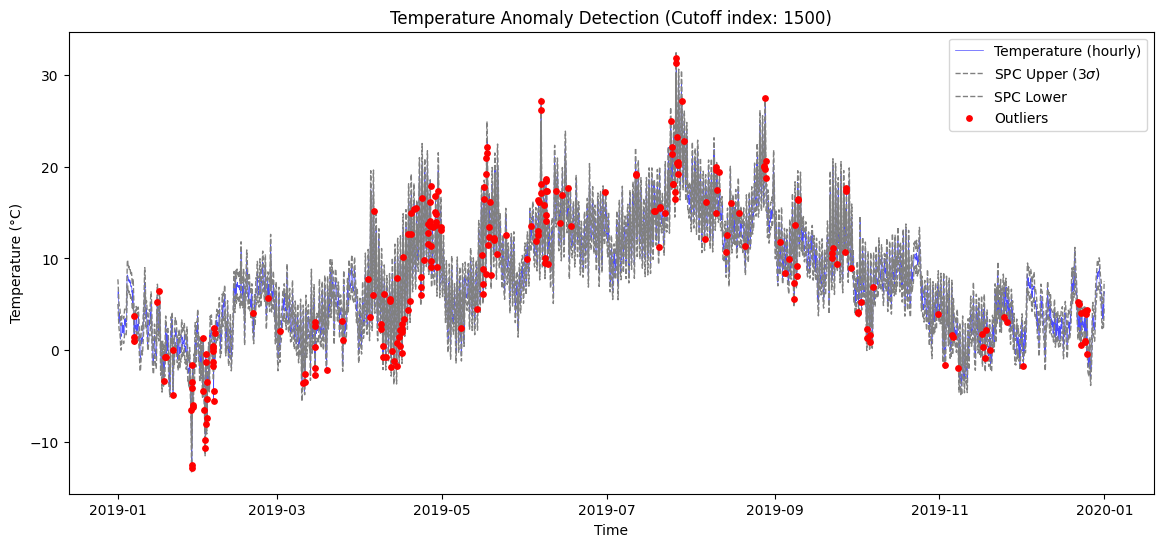

252 outliers detected out of 8760 samples


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct, idct
from typing import Dict, Any

def temp_outlier_dct_spc_trend(df: pd.DataFrame, 
                               temp_col: str = "temperature_2m", 
                               time_col: str = "time",
                               # CHANGED: Increased cutoff to 1500 to include daily cycle in the trend
                               freq_cutoff: int = 1500, 
                               n_std: float = 3.0, 
                               plot: bool = True) -> Dict[str, Any]:
    
    # Sort and reset index
    df = df.sort_values(time_col).reset_index(drop=True)
    temps = df[temp_col].to_numpy(dtype=float)
    n = len(temps)
    
    if freq_cutoff >= n:
        raise ValueError("freq_cutoff must be less than number of samples")

    # DCT: Convert to frequency domain
    coeffs = dct(temps, norm="ortho")

    # 1. Calculate SATV (High-Pass)
    # We zero out the low frequencies (Trend + Daily Cycle) to isolate anomalies
    hp_coeffs = coeffs.copy()
    hp_coeffs[:freq_cutoff] = 0
    residual = idct(hp_coeffs, norm="ortho") # This is the SATV (Noise only)

    # 2. Calculate Trend (Low-Pass)
    # We zero out high frequencies (Noise) to keep Trend + Daily Cycle
    lp_coeffs = coeffs.copy()
    lp_coeffs[freq_cutoff:] = 0
    trend = idct(lp_coeffs, norm="ortho") # This is Trend + Daily Cycle

    # 3. Robust Statistics on Residual (SATV)
    med = np.median(residual)
    mad = np.median(np.abs(residual - med))
    robust_std = mad * 1.4826

    # 4. Define Boundaries
    # FIX: We must multiply n_std by robust_std
    upper = trend + med + (n_std * robust_std)
    lower = trend + med - (n_std * robust_std)

    # Identify Outliers
    outlier_mask = (temps > upper) | (temps < lower)

    # Plotting
    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(df[time_col], temps, label="Temperature (hourly)", color='blue', linewidth=0.5, alpha=0.7)
        
        # Plot the borders
        # FIX: Added 'r' before 'f' (rf"...") to handle the backslash in \sigma correctly
        plt.plot(df[time_col], upper, color="gray", linestyle="--", linewidth=1, label=rf"SPC Upper ({n_std}$\sigma$)")
        plt.plot(df[time_col], lower, color="gray", linestyle="--", linewidth=1, label=f"SPC Lower")
        
        # Highlight outliers
        plt.scatter(df[time_col][outlier_mask], temps[outlier_mask], color="red", s=15, label="Outliers", zorder=3)
        
        plt.title(f"Temperature Anomaly Detection (Cutoff index: {freq_cutoff})")
        plt.ylabel("Temperature (°C)")
        plt.xlabel("Time")
        plt.legend(loc='upper right')
        plt.show()

    # Summary
    summary = {
        "n_samples": n,
        "n_outliers": int(outlier_mask.sum()),
        "outlier_fraction": float(outlier_mask.sum() / max(1, n)),
        "median_residual": float(med),
        "robust_std_residual": float(robust_std),
        "outlier_indices": np.where(outlier_mask)[0],
        "outlier_times": df[time_col][outlier_mask].tolist()
    }
    return summary

# Apply the outlier detection function to Bergen 2019 data
# Use 1500 to ensure the borders "follow the curve"
summary = temp_outlier_dct_spc_trend(bergen2019, freq_cutoff=1500, n_std=3)

print(f"{summary['n_outliers']} outliers detected out of {summary['n_samples']} samples")

## Precipitation Anomaly Detection Using Local Outlier Factor (LOF)

In this task, we detect anomalies in hourly precipitation data for Bergen (2019) using the **Local Outlier Factor (LOF)** method:

- **Preprocessing:** The precipitation data is sorted by time, and any missing values are filled with zero to ensure finite inputs for LOF.
- **LOF anomaly detection:** The algorithm assigns an outlier score to each observation based on its local neighborhood density. 
Observations with unusually low density are flagged as anomalies.
- **Parameters:**  
  - `outlier_prop` sets the proportion of data to be considered outliers (default: 1%).  
- **Visualization:** The precipitation time series is plotted, with detected anomalies highlighted in red.
- **Output:** The function returns a summary dictionary containing the number of samples, number of anomalies, anomaly fraction, indices and timestamps of detected anomalies, and LOF scores.

This method helps to detect **rare or extreme precipitation events** in a robust and automated way.


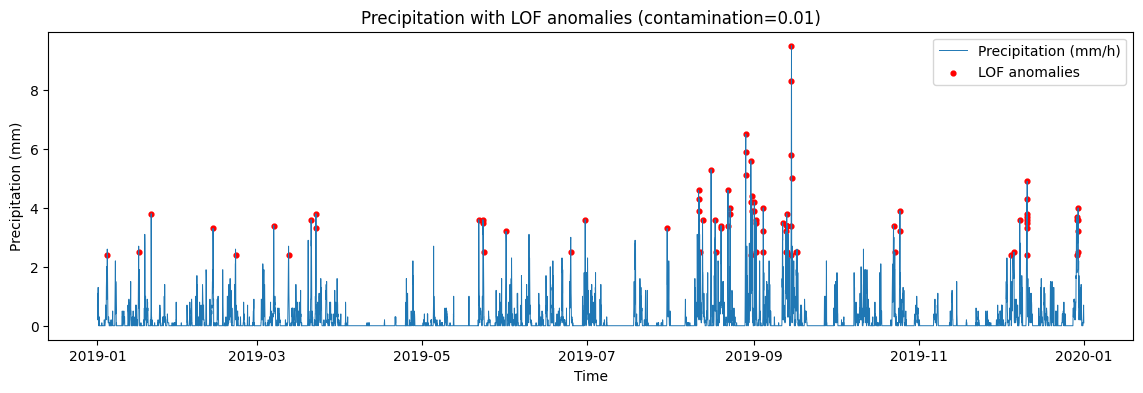

86 precipation anomalies


In [5]:
def precip_lof_anomalies(df: pd.DataFrame,
                         precip_col: str = "precipitation", time_col: str = "time",
                         outlier_prop: float = 0.01, plot: bool = True) -> Dict[str, Any]:

    # Sort data by time and reset index for consistency
    df = df.sort_values(time_col).reset_index(drop=True)
    
    # Prepare feature matrix for LOF; fill missing values with 0 (LOF requires finite numbers)
    X = df[[precip_col]].fillna(0).to_numpy(dtype=float)
    n_samples = len(X)
    
    # Determine number of neighbors for LOF: typical heuristic sqrt(n) or at least 5, max 50
    n_neighbors = min(max(5, int(np.sqrt(n_samples))), 50)
    
    # Initialize LOF model with contamination = outlier proportion
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=outlier_prop)
    
    # Fit LOF and predict outliers: -1 = outlier, 1 = inlier
    y_pred = lof.fit_predict(X)
    anomaly_mask = (y_pred == -1)  # Boolean mask for anomalies
    
    # Plot precipitation and highlight anomalies if requested
    if plot:
        plt.figure(figsize=(14,4))
        plt.plot(df[time_col], df[precip_col], label="Precipitation (mm/h)", linewidth=0.7)
        plt.scatter(df[time_col][anomaly_mask], df[precip_col][anomaly_mask], color="red", s=12, label="LOF anomalies")
        plt.title(f"Precipitation with LOF anomalies (contamination={outlier_prop})")
        plt.xlabel("Time")
        plt.ylabel("Precipitation (mm)")
        plt.legend()
        plt.show()
    
    # Negative outlier factor scores; higher => more anomalous
    scores = -lof.negative_outlier_factor_
    
    # Prepare summary dictionary
    summary = {"n_samples": n_samples, "n_anomalies": int(anomaly_mask.sum()), 
               "anomaly_fraction": float(anomaly_mask.sum() / max(1, n_samples)),
               "anomaly_indices": np.where(anomaly_mask)[0], 
               "anomaly_times": df[time_col][anomaly_mask].tolist(), "scores": scores}
    
    return summary

# Apply the LOF anomaly detection function to Bergen 2019 precipitation data
pa = precip_lof_anomalies(bergen2019, outlier_prop=0.01)
print(pa["n_anomalies"], "precipation anomalies")


## STL Decomposition of Elhub Production Data

In this task, we perform **Seasonal-Trend decomposition (STL)** on hourly electricity production data from Elhub.

**Data Preparation:**  
   - Load the CSV file containing production data.  
   - Filter by electricity price area and production group.  
   - Convert timestamps to a regular hourly time series, interpolating missing values.

**STL Decomposition:**  
   - Use LOESS-based STL decomposition to separate the series into **trend**, **seasonal**, and **residual** components.  
   - Parameters such as `period`, `seasonal`, `trend`, and `robust` can be adjusted, with sensible defaults.


This method allows for **detailed inspection of seasonal patterns and underlying trends** in electricity production data.


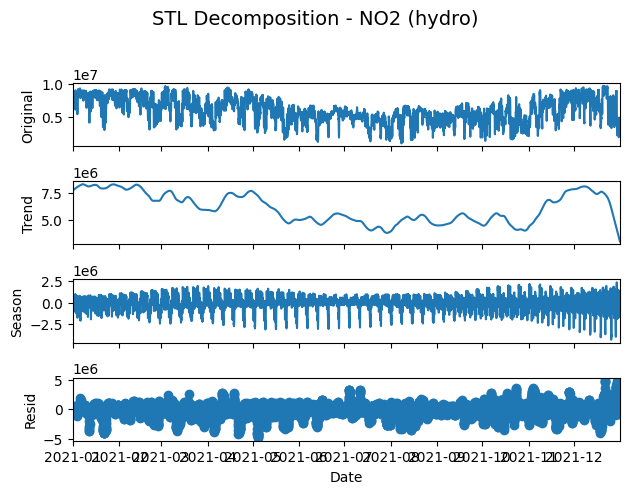

In [ ]:
def stl_decompose_elhub_from_csv(csv_path: str, # Path to Elhub CSV file
                                 price_area: str, # Electricity price area (e.g., 'NO1', 'NO2')
                                 production_group: str, # Production type (e.g., 'hydro', 'wind')
                                 period: int = 24 * 7,  # weekly cycle for hourly data
                                 seasonal: int = 13,  # seasonal smoother length
                                 trend: int = 301,  # trend smoother length
                                 robust: bool = True): # whether to use robust fitting to handle outliers

    # Load CSV file
    df = pd.read_csv(csv_path)

    # Parse timestamps as UTC, then convert to Oslo timezone
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True).dt.tz_convert("Europe/Oslo")


    # Filter data by price area and production group
    df_filtered = df[(df["priceArea"] == price_area) & 
        (df["productionGroup"] == production_group)][["startTime", "quantityKwh"]].dropna().sort_values("startTime")

    if df_filtered.empty:
        raise ValueError(f"No matching data found for {price_area} - {production_group}")

    # Convert filtered data to a regular hourly time series, interpolating missing values
    series = df_filtered.set_index("startTime")["quantityKwh"].asfreq("h").interpolate(method="time")

    # Validate parameters
    if period < 2:
        raise ValueError("period must be >= 2")
    
    # Adjust trend and seasonal parameters to meet STL requirements
    if trend <= period:
        trend = period + 1 if period % 2 == 0 else period + 2
        print(f"Adjusted trend to {trend} (must be > period)")
    if trend % 2 == 0:
        trend += 1  # ensure trend is odd
    if seasonal < 3:
        seasonal = 3
    if seasonal % 2 == 0:
        seasonal += 1  # ensure seasonal is odd

    # Perform STL decomposition
    stl = STL(series, period=period, seasonal=seasonal, trend=trend, robust=robust)
    result = stl.fit()

    # Plot decomposition components
    fig = result.plot()
    fig.suptitle(f"STL Decomposition - {price_area} ({production_group})", fontsize=14, y=1.02)

    # Adjust subplot titles and axis labels for clarity
    for ax in fig.get_axes():
        ax.set_title("")
    axes = fig.get_axes()
    axes[0].set_ylabel("Original")
    axes[-1].set_xlabel("Date")

    fig.tight_layout()
    fig.autofmt_xdate()
    plt.show()

    return fig

# Example usage
fig = stl_decompose_elhub_from_csv("elhub_2021_production.csv", "NO2", "hydro")


## Spectrogram of Electricity Production

This task computes and visualizes a **spectrogram** for hourly electricity production data from Elhub:

**Data preparation:**  
   - Reads CSV data and filters for a selected price area and production group.  
   - Resamples to a regular hourly frequency and interpolates missing values.  

**Spectrogram computation:**  
   - Computes the spectrogram using `scipy.signal.spectrogram` with configurable `window_length` and `window_overlap`.  
   - Converts the power spectrum to decibels for visualization.  
---------
- `window_length` (int): Number of samples per FFT segment (controls frequency resolution).
- `window_overlap` (int): Number of overlapping samples between segments (controls smoothing).





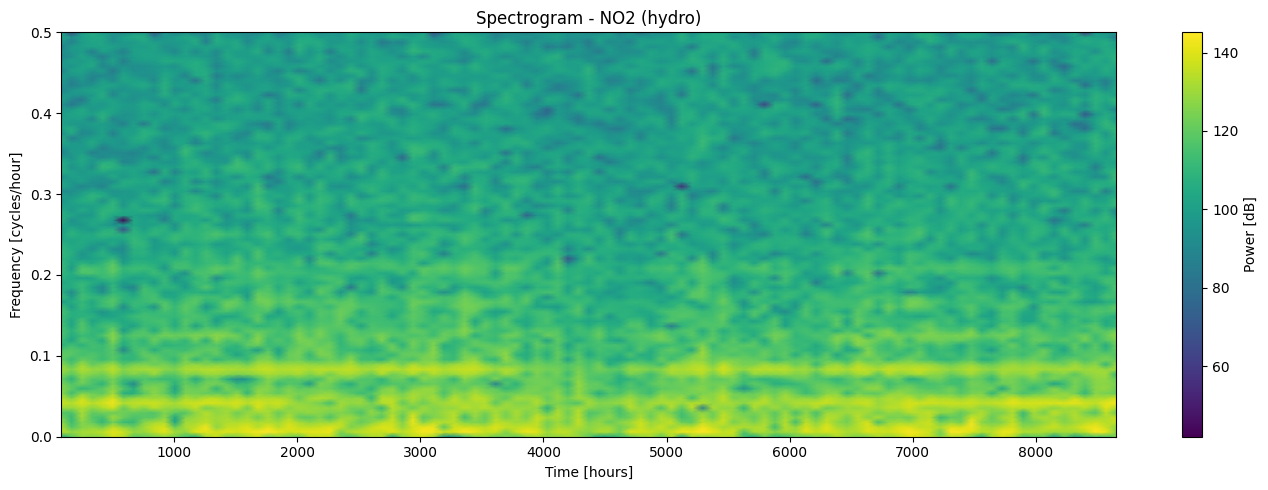

Spectrogram complete for NO2 - hydro


In [ ]:
def elhub_spectrogram(csv_path: str,
                      price_area: str,
                      production_group: str,
                      window_length: int = 168,   # default: 1 week (hourly data)
                      window_overlap: int = 84):  # default: 50% overlap


    # Load data
    df = pd.read_csv(csv_path)
    
    # Parse timestamps as UTC, then convert to Oslo timezone
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True).dt.tz_convert("Europe/Oslo")

    # Filter data by price area and production group
    df_filtered = df[(df["priceArea"] == price_area) &
        (df["productionGroup"] == production_group)][["startTime", "quantityKwh"]].dropna().sort_values("startTime")

    if df_filtered.empty:
        raise ValueError(f"No matching data found for {price_area} - {production_group}")

    # Resample to regular hourly frequency and interpolate missing values
    series = (df_filtered.set_index("startTime")["quantityKwh"].asfreq("h").interpolate(method="time"))
    data = series.values
    n = len(data)

    # Validate parameters
    if window_length >= n:
        raise ValueError(f"window_length ({window_length}) must be smaller than number of samples ({n})")
    if window_overlap >= window_length:
        raise ValueError("window_overlap must be smaller than window_length")

    f, t, Sxx = spectrogram(data,
        fs=1.0,    # 1 sample per hour
        window='hann',    
        nperseg=window_length,  # number of samples per FFT segment
        noverlap=window_overlap, # number of overlapping samples between segments
        scaling='density',  # output power spectral density (PSD)
        mode='psd')      # compute power spectral density


    # Prevent log of zero
    Sxx_db = 10 * np.log10(np.maximum(Sxx, 1e-12))

    #Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='viridis') # colormap

    # In elhub_spectrogram function, after defining ax:
    ax.set_ylabel('Frequency [cycles/hour]')
    ax.set_xlabel('Time [hours]')
    ax.set_ylim(0, 0.1) #zoom in on the important cycles
    ax.set_title(f"Spectrogram - {price_area} ({production_group})")
    fig.colorbar(im, ax=ax, label='Power [dB]')
    fig.tight_layout()
    plt.show()

    print(f"Spectrogram complete for {price_area} - {production_group}")
    
    return fig


# Example usage 
fig = elhub_spectrogram("elhub_2021_production.csv", "NO2", "hydro", 168, 84)
